In [3]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Trying to import the csv

In [4]:
# Load your data
imfeatures = pd.read_csv(r"C:\Users\k8pod\BDSICDS\imagingFeatures.csv")
imfeatures = imfeatures.dropna()

# Load the second dataset
clinical_data = pd.read_csv(r"C:\Users\k8pod\BDSICDS\clinicalData_clean.csv")
print(clinical_data.columns)
print(clinical_data[['ER', 'PR', 'HER2']])
#clinical_data = clinical_data.dropna() # It's good practice to handle NaNs in both dataframes

# Merge the two dataframes using an inner join on 'Patient_ID'
# The .merge() method takes the other DataFrame as the first argument,
# and 'on' is used to specify the common column for merging.
merged = imfeatures.merge(clinical_data, on='Patient ID', how='inner')
#merged['Mol Subtype']

Index(['Unnamed: 0', 'Patient ID', 'Days to MRI (From the Date of Diagnosis)',
       'Manufacturer', 'Manufacturer Model Name', 'Scan Options',
       'Field Strength (Tesla)', 'Patient Position During MRI',
       'Image Position of Patient', 'Contrast Agent',
       'Contrast Bolus Volume (mL)', 'TR (Repetition Time)', 'TE (Echo Time)',
       'Acquisition Matrix', 'Slice Thickness', 'Rows', 'Columns',
       'Reconstruction Diameter', 'Flip Angle \r\n',
       'FOV Computed (Field of View) in cm', 'Date of Birth (Days)',
       'Menopause (at diagnosis)', 'Race and Ethnicity',
       'Metastatic at Presentation (Outside of Lymph Nodes)', 'ER', 'PR',
       'HER2', 'Mol Subtype', 'Oncotype score', 'Staging(Tumor Size)# [T]',
       'Staging(Nodes)#(Nx replaced by -1)[N]',
       'Staging(Metastasis)#(Mx -replaced by -1)[M]', 'TumorGradeT',
       'TumorGradeN', 'TumorGradeM', 'Nottingham grade', 'Histologic type',
       'Tumor Location', 'Position', 'Bilateral Information',
       

In [6]:
# Step 1: Drop non-feature columns (like ID)
imfeatures = imfeatures.drop(columns=["Unnamed: 0", "Patient ID"], errors="ignore")

imfeatures

,"F1_DT_POSTCON (T11=0.05,T12=0.5)","F1_DT_POSTCON (T11=0.05,T12=0.1)","F1_DT_POSTCON (T11=0.02,T12=0.5)","F1_DT_POSTCON (T11=0.02,T12=0.8)","F1_DT_POSTCON (T11=0.05,T12=0.8)","F1_DT_POSTCON (T11=0.1,T12=0.5)","F1_DT_POSTCON (T11=0.1,T12=0.8)","F1_DT_POSTCON (T11=0.2,T12=0.5)","F1_DT_POSTCON (T11=0.2,T12=0.8)","F1_DT_T1NFS (T11=0.05,T12=0.5)",...,WashinRate_map_difference_entropy_tissue_PostCon,WashinRate_map_information_measure_correlation1_tissue_PostCon,WashinRate_map_information_measure_correlation2_tissue_PostCon,WashinRate_map_inverse_difference_is_homom_tissue_PostCon,WashinRate_map_inverse_difference_normalized_tissue_PostCon,WashinRate_map_inverse_difference_moment_normalized_tissue_PostCon,WashinRate_map_mean_tissue_PostCon,WashinRate_map_std_dev_tissue_PostCon,WashinRate_map_skewness_tissue_PostCon,WashinRate_map_kurtosis_tissue_PostCon
0,1.000000,0.120721,0.530395,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,...,3.380663,-0.025575,0.422391,0.171959,0.960359,0.996829,14.517894,20.347506,1.625870,11.406955
1,1.000000,0.129546,0.485217,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,0.432916,...,3.444474,-0.036063,0.505652,0.177087,0.959067,0.996363,47.297950,83.909561,0.251498,5.659428
2,0.174775,0.062051,0.069910,0.132265,0.330662,0.349550,0.661324,0.699100,1.00000,0.185670,...,3.478455,-0.043730,0.546674,0.170507,0.957527,0.995981,114.171582,129.252342,1.928743,11.554948
4,0.289669,0.052031,0.115868,0.378575,0.839984,0.579338,1.000000,0.958287,1.00000,0.392859,...,4.009938,-0.049294,0.603426,0.117966,0.930624,0.989135,34.406635,26.951415,0.985464,4.331451
5,0.297156,0.074791,0.118862,0.253568,0.633921,0.594311,1.000000,1.000000,1.00000,0.445015,...,3.546936,-0.045549,0.561651,0.166956,0.954940,0.995613,277.427199,252.568247,1.014581,5.344516
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
916,0.091844,0.050240,0.036738,0.103783,0.259457,0.183688,0.518915,0.367377,0.90289,0.125807,...,3.948053,-0.090354,0.754825,0.135670,0.935277,0.989856,591.035965,397.002913,0.449477,2.857014
917,0.587345,0.115746,0.234938,0.479802,1.000000,1.000000,1.000000,1.000000,1.00000,0.336273,...,3.116735,-0.050326,0.565456,0.223324,0.970250,0.997982,30.665570,65.018278,1.563114,12.928674
919,0.742209,0.058729,0.296884,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,0.609958,...,3.369220,-0.050465,0.572790,0.178169,0.961318,0.996820,17.724748,18.299933,2.282520,13.460166
920,0.381016,0.089668,0.152406,0.256513,0.641281,0.768252,1.000000,1.000000,1.00000,0.313589,...,3.191276,-0.103623,0.750372,0.218098,0.968191,0.997618,149.643082,157.235282,1.318530,9.176372


In [7]:
# Step 2: Standardize all features (z-score)
scaler = StandardScaler()
standardized_data = scaler.fit_transform(imfeatures)

In [8]:
# Step 3: Convert back to DataFrame with original column names
standardized_imfeatures = pd.DataFrame(standardized_data, columns=imfeatures.columns)

In [9]:
# Optional: Save the standardized data
standardized_imfeatures.to_csv("imagingFeatures_standardized_all.csv", index=False)

In [10]:
standardized_imfeatures

,"F1_DT_POSTCON (T11=0.05,T12=0.5)","F1_DT_POSTCON (T11=0.05,T12=0.1)","F1_DT_POSTCON (T11=0.02,T12=0.5)","F1_DT_POSTCON (T11=0.02,T12=0.8)","F1_DT_POSTCON (T11=0.05,T12=0.8)","F1_DT_POSTCON (T11=0.1,T12=0.5)","F1_DT_POSTCON (T11=0.1,T12=0.8)","F1_DT_POSTCON (T11=0.2,T12=0.5)","F1_DT_POSTCON (T11=0.2,T12=0.8)","F1_DT_T1NFS (T11=0.05,T12=0.5)",...,WashinRate_map_difference_entropy_tissue_PostCon,WashinRate_map_information_measure_correlation1_tissue_PostCon,WashinRate_map_information_measure_correlation2_tissue_PostCon,WashinRate_map_inverse_difference_is_homom_tissue_PostCon,WashinRate_map_inverse_difference_normalized_tissue_PostCon,WashinRate_map_inverse_difference_moment_normalized_tissue_PostCon,WashinRate_map_mean_tissue_PostCon,WashinRate_map_std_dev_tissue_PostCon,WashinRate_map_skewness_tissue_PostCon,WashinRate_map_kurtosis_tissue_PostCon
0,1.898017,0.791441,1.377394,1.746207,1.080013,1.235811,0.672063,0.696554,0.342477,2.469875,...,-0.127296,1.125159,-1.327434,-0.233161,0.221347,0.450227,-0.836444,-0.920307,0.036994,-0.084546
1,1.898017,0.955974,1.182981,1.746207,1.080013,1.235811,0.672063,0.696554,0.342477,0.198198,...,0.047559,0.626576,-0.483970,-0.133400,0.128963,0.288776,-0.614330,-0.449281,-1.266008,-0.084569
2,-0.791197,-0.302303,-0.604213,-0.824636,-0.982887,-0.921828,-0.703374,-0.681431,0.342477,-0.792241,...,0.140673,0.262104,-0.068406,-0.261412,0.018903,0.156444,-0.161201,-0.113269,0.324139,-0.084546
3,-0.416785,-0.489109,-0.406444,-0.094890,0.586843,-0.159588,0.672063,0.505528,0.342477,0.037734,...,1.597036,-0.002384,0.506513,-1.283458,-1.904114,-2.215655,-0.701680,-0.871368,-0.570157,-0.084575
4,-0.392387,-0.064796,-0.393557,-0.465249,-0.048244,-0.109918,0.672063,0.696554,0.342477,0.246665,...,0.328323,0.175663,0.083314,-0.330482,-0.166040,0.028843,0.945002,0.800562,-0.542551,-0.084571
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
856,-1.061449,-0.522488,-0.746964,-0.909019,-1.202340,-1.472015,-1.281730,-2.200571,-0.499945,-1.032046,...,1.427459,-1.954300,2.040245,-0.939074,-1.571518,-1.965662,3.069982,1.870894,-1.078309,-0.084581
857,0.553270,0.698694,0.105952,0.205013,1.080013,1.235811,0.672063,0.696554,0.342477,-0.188943,...,-0.850507,-0.051451,0.121860,0.766020,0.928356,0.849904,-0.727029,-0.589274,-0.022503,-0.084540
858,1.057936,-0.364225,0.372523,1.746207,1.080013,1.235811,0.672063,0.696554,0.342477,0.907408,...,-0.158651,-0.058056,0.196165,-0.112360,0.289898,0.447085,-0.814714,-0.935480,0.659545,-0.084538
859,-0.119106,0.212540,-0.249206,-0.456526,-0.025557,0.467067,0.672063,0.696554,0.342477,-0.279812,...,-0.646252,-2.585089,1.995127,0.664356,0.781141,0.723552,0.079150,0.094099,-0.254386,-0.084555


In [11]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# Load the standardized data
df = pd.read_csv("imagingFeatures_standardized_all.csv")
df

,"F1_DT_POSTCON (T11=0.05,T12=0.5)","F1_DT_POSTCON (T11=0.05,T12=0.1)","F1_DT_POSTCON (T11=0.02,T12=0.5)","F1_DT_POSTCON (T11=0.02,T12=0.8)","F1_DT_POSTCON (T11=0.05,T12=0.8)","F1_DT_POSTCON (T11=0.1,T12=0.5)","F1_DT_POSTCON (T11=0.1,T12=0.8)","F1_DT_POSTCON (T11=0.2,T12=0.5)","F1_DT_POSTCON (T11=0.2,T12=0.8)","F1_DT_T1NFS (T11=0.05,T12=0.5)",...,WashinRate_map_difference_entropy_tissue_PostCon,WashinRate_map_information_measure_correlation1_tissue_PostCon,WashinRate_map_information_measure_correlation2_tissue_PostCon,WashinRate_map_inverse_difference_is_homom_tissue_PostCon,WashinRate_map_inverse_difference_normalized_tissue_PostCon,WashinRate_map_inverse_difference_moment_normalized_tissue_PostCon,WashinRate_map_mean_tissue_PostCon,WashinRate_map_std_dev_tissue_PostCon,WashinRate_map_skewness_tissue_PostCon,WashinRate_map_kurtosis_tissue_PostCon
0,1.898017,0.791441,1.377394,1.746207,1.080013,1.235811,0.672063,0.696554,0.342477,2.469875,...,-0.127296,1.125159,-1.327434,-0.233161,0.221347,0.450227,-0.836444,-0.920307,0.036994,-0.084546
1,1.898017,0.955974,1.182981,1.746207,1.080013,1.235811,0.672063,0.696554,0.342477,0.198198,...,0.047559,0.626576,-0.483970,-0.133400,0.128963,0.288776,-0.614330,-0.449281,-1.266008,-0.084569
2,-0.791197,-0.302303,-0.604213,-0.824636,-0.982887,-0.921828,-0.703374,-0.681431,0.342477,-0.792241,...,0.140673,0.262104,-0.068406,-0.261412,0.018903,0.156444,-0.161201,-0.113269,0.324139,-0.084546
3,-0.416785,-0.489109,-0.406444,-0.094890,0.586843,-0.159588,0.672063,0.505528,0.342477,0.037734,...,1.597036,-0.002384,0.506513,-1.283458,-1.904114,-2.215655,-0.701680,-0.871368,-0.570157,-0.084575
4,-0.392387,-0.064796,-0.393557,-0.465249,-0.048244,-0.109918,0.672063,0.696554,0.342477,0.246665,...,0.328323,0.175663,0.083314,-0.330482,-0.166040,0.028843,0.945002,0.800562,-0.542551,-0.084571
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
856,-1.061449,-0.522488,-0.746964,-0.909019,-1.202340,-1.472015,-1.281730,-2.200571,-0.499945,-1.032046,...,1.427459,-1.954300,2.040245,-0.939074,-1.571518,-1.965662,3.069982,1.870894,-1.078309,-0.084581
857,0.553270,0.698694,0.105952,0.205013,1.080013,1.235811,0.672063,0.696554,0.342477,-0.188943,...,-0.850507,-0.051451,0.121860,0.766020,0.928356,0.849904,-0.727029,-0.589274,-0.022503,-0.084540
858,1.057936,-0.364225,0.372523,1.746207,1.080013,1.235811,0.672063,0.696554,0.342477,0.907408,...,-0.158651,-0.058056,0.196165,-0.112360,0.289898,0.447085,-0.814714,-0.935480,0.659545,-0.084538
859,-0.119106,0.212540,-0.249206,-0.456526,-0.025557,0.467067,0.672063,0.696554,0.342477,-0.279812,...,-0.646252,-2.585089,1.995127,0.664356,0.781141,0.723552,0.079150,0.094099,-0.254386,-0.084555


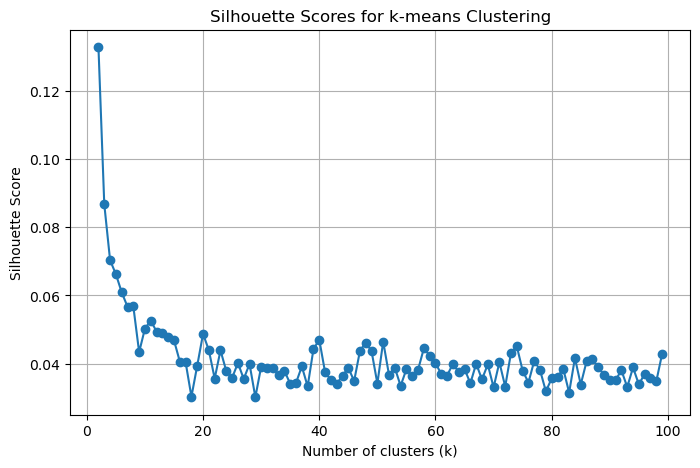

In [12]:
# Try k from 2 to 100
silhouette_scores = []
cluster_results = {}

for k in range(2, 100):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(df)
    silhouette = silhouette_score(df, labels)
    silhouette_scores.append(silhouette)
    cluster_results[k] = labels

# Plot the silhouette scores
plt.figure(figsize=(8, 5))
plt.plot(range(2, 100), silhouette_scores, marker='o')
plt.title("Silhouette Scores for k-means Clustering")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette Score")
plt.grid(True)
plt.show()

In [13]:
# Perform K-Means clustering on the standardized imaging data (full dimensionality)
best_k = 7 # Or your chosen k
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10) # n_init is important for robust results
labels = kmeans.fit_predict(standardized_imfeatures)

# Add cluster labels to the original merged DataFrame
merged['Cluster'] = labels

# Create a table to see results (cross-tabulation of cluster vs. molecular subtype)
# Ensure 'Subtype' column exists in your clinical_data and thus in 'merged'
print("K-Means Cluster Distribution by Molecular Features")

# If you want a confusion matrix, you need both a predicted and a true label.
# Here, 'cluster' is the predicted group from KMeans, and 'Mol Subtype' is the true label.
# The crosstab below is correct for showing overlap between clusters and true subtypes.
#table = pd.crosstab(merged['Cluster'], merged[['ER', 'PR', 'HER2']])

merged['Mol Subtype'] = merged['ER'].astype(str) + '/' + merged['PR'].astype(str) + '/' + merged['HER2'].astype(str)
table = pd.crosstab(merged['Cluster'], merged['Mol Subtype'])
print(table)

#print(table)



K-Means Cluster Distribution by Molecular Features
Mol Subtype  0/0/0  0/0/1  0/1/0  0/1/1  1/0/0  1/0/1  1/1/0  1/1/1
Cluster                                                            
0               25     10      2      1      8      1     65      9
1               31     16      2      1     19      9     95     13
2               23     10      0      0      9      1     55      6
3                9      6      0      0      6      1     32      8
4               37      6      6      1     19      3    114     11
5               24      5      0      0     11      5     78     23
6                9      5      0      0      1      4     23      3


In [14]:
# Optional: Add percentages to the table for better interpretation
print("\n--- K-Means Cluster Distribution by Molecular Subtype (Percentages within each cluster) ---")
table_percent = table.apply(lambda r: r/r.sum(), axis=1) * 100
pd.set_option('display.max_rows', None)
print(table_percent.round(2))
pd.reset_option('all')


--- K-Means Cluster Distribution by Molecular Subtype (Percentages within each cluster) ---
Mol Subtype  0/0/0  0/0/1  0/1/0  0/1/1  1/0/0  1/0/1  1/1/0  1/1/1
Cluster                                                            
0            20.66   8.26   1.65   0.83   6.61   0.83  53.72   7.44
1            16.67   8.60   1.08   0.54  10.22   4.84  51.08   6.99
2            22.12   9.62   0.00   0.00   8.65   0.96  52.88   5.77
3            14.52   9.68   0.00   0.00   9.68   1.61  51.61  12.90
4            18.78   3.05   3.05   0.51   9.64   1.52  57.87   5.58
5            16.44   3.42   0.00   0.00   7.53   3.42  53.42  15.75
6            20.00  11.11   0.00   0.00   2.22   8.89  51.11   6.67


C:\Users\k8pod\AppData\Local\Temp\ipykernel_5144\1822477023.py:6: FutureWarning: data_manager option is deprecated and will be removed in a future version. Only the BlockManager will be available.
  pd.reset_option('all')
C:\Users\k8pod\AppData\Local\Temp\ipykernel_5144\1822477023.py:6: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  pd.reset_option('all')


In [15]:
import numpy as np

def entropy(counts):
    probs = counts / np.sum(counts)
    return -np.sum(probs * np.log2(probs + 1e-10))  # add small value to avoid log(0)

# For KMeans clusters
kmeans_entropy = table.apply(entropy, axis=1)
print("\n--- Entropy for each KMeans cluster ---")
print(kmeans_entropy)


--- Entropy for each KMeans cluster ---
Cluster
0    1.999037
1    2.157105
2    1.899718
3    2.025989
4    1.905107
5    1.945883
6    2.004391
dtype: float64


In [16]:
# subspace clustering, projection clustering, bootstrap, correlation ... 
#more high dimensional clustering techniques 

# Gaussian Mixture Model

from sklearn.mixture import GaussianMixture

# Choose the number of clusters (you can tune this, e.g., using BIC/AIC)
n_components = 7  # Try different values as needed

# Fit GMM
gmm = GaussianMixture(n_components=n_components, random_state=42)
gmm_labels = gmm.fit_predict(standardized_imfeatures)

# Add GMM cluster labels to merged DataFrame
merged['GMM_Cluster'] = gmm_labels

# Crosstab: GMM cluster vs. molecular subtype
print("--- GMM Cluster Distribution by Molecular Subtype ---")
merged['Mol Subtype'] = merged['ER'].astype(str) + '/' + merged['PR'].astype(str) + '/' + merged['HER2'].astype(str)
table = pd.crosstab(merged['GMM_Cluster'], merged['Mol Subtype'])
print(table)

--- GMM Cluster Distribution by Molecular Subtype ---
Mol Subtype  0/0/0  0/0/1  0/1/0  0/1/1  1/0/0  1/0/1  1/1/0  1/1/1
GMM_Cluster                                                        
0                8      6      0      0      4      1     32      7
1               34      8      4      0     20      4    100     14
2               12      5      0      0      4      4     39      5
3               25      6      0      0      7      6     66     18
4               17      6      1      1      9      1     70     10
5               37     17      3      1     13      6     80     10
6               25     10      2      1     16      2     75      9


In [17]:
# Optional: Percentages within each cluster
print("\n--- GMM Cluster Distribution by Molecular Subtype (Percentages within each cluster) ---")
gmm_table_percent = table.apply(lambda r: r/r.sum(), axis=1) * 100
print(gmm_table_percent.round(2))


--- GMM Cluster Distribution by Molecular Subtype (Percentages within each cluster) ---
Mol Subtype  0/0/0  0/0/1  0/1/0  0/1/1  1/0/0  1/0/1  1/1/0  1/1/1
GMM_Cluster                                                        
0            13.79  10.34   0.00   0.00   6.90   1.72  55.17  12.07
1            18.48   4.35   2.17   0.00  10.87   2.17  54.35   7.61
2            17.39   7.25   0.00   0.00   5.80   5.80  56.52   7.25
3            19.53   4.69   0.00   0.00   5.47   4.69  51.56  14.06
4            14.78   5.22   0.87   0.87   7.83   0.87  60.87   8.70
5            22.16  10.18   1.80   0.60   7.78   3.59  47.90   5.99
6            17.86   7.14   1.43   0.71  11.43   1.43  53.57   6.43


In [19]:
# For GMM clusters
gmm_entropy = table.apply(entropy, axis=1)
print("\n--- Entropy for each GMM cluster ---")
print(gmm_entropy)


--- Entropy for each GMM cluster ---
GMM_Cluster
0    1.941408
1    1.995840
2    1.929256
3    1.994093
4    1.838576
5    2.176635
6    2.036380
dtype: float64


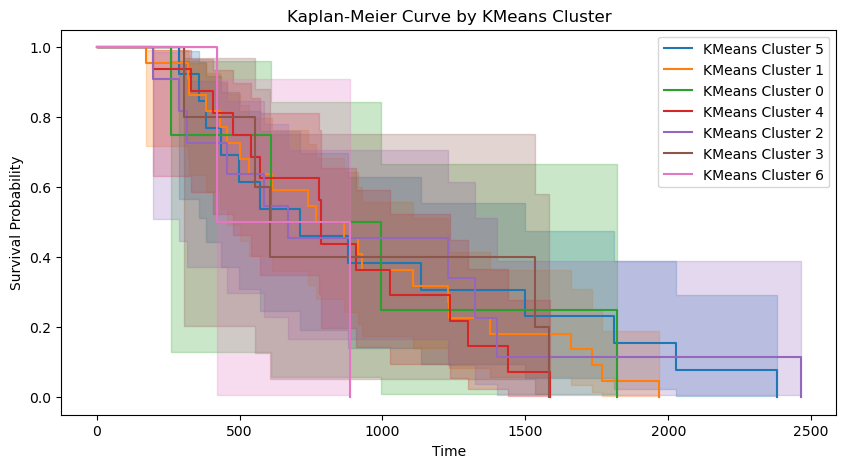

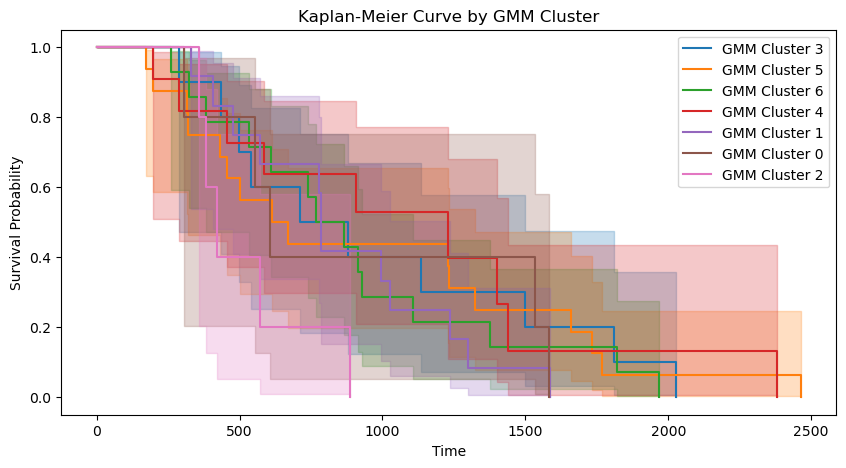

In [20]:
from lifelines import KaplanMeierFitter
import matplotlib.pyplot as plt

# Make sure your merged DataFrame has columns 'Time', 'Status', 'Cluster', and 'GMM_Cluster'
# 'Time' = survival time, 'Status' = event occurred (1=event, 0=censored)

kmf = KaplanMeierFitter()

# For KMeans clusters
plt.figure(figsize=(10, 5))
for cluster in merged['Cluster'].unique():
    mask = merged['Cluster'] == cluster
    # Select only rows where both columns are not null and not 'NP'
    sub = merged.loc[mask].copy()
    sub = sub[
        (sub['Days to distant recurrence(from the date of diagnosis)'].notnull()) &
        (sub['Recurrence event(s)'].notnull()) &
        (sub['Days to distant recurrence(from the date of diagnosis)'] != 'NP') &
        (sub['Recurrence event(s)'] != 'NP')
    ]
    # If needed, convert time/event columns to numeric
    sub['Days to distant recurrence(from the date of diagnosis)'] = pd.to_numeric(sub['Days to distant recurrence(from the date of diagnosis)'])
    sub['Recurrence event(s)'] = pd.to_numeric(sub['Recurrence event(s)'])
    if len(sub) > 0:
        kmf.fit(
            sub['Days to distant recurrence(from the date of diagnosis)'],
            sub['Recurrence event(s)'],
            label=f'KMeans Cluster {cluster}'
        )
        kmf.plot_survival_function()
plt.title('Kaplan-Meier Curve by KMeans Cluster')
plt.xlabel('Time')
plt.ylabel('Survival Probability')
plt.legend()
plt.show()


# For GMM clusters
plt.figure(figsize=(10, 5))
for cluster in merged['GMM_Cluster'].unique():
    mask = merged['GMM_Cluster'] == cluster
    # Select only rows where both columns are not null and not 'NP'
    sub = merged.loc[mask].copy()
    sub = sub[
        (sub['Days to distant recurrence(from the date of diagnosis)'].notnull()) &
        (sub['Recurrence event(s)'].notnull()) &
        (sub['Days to distant recurrence(from the date of diagnosis)'] != 'NP') &
        (sub['Recurrence event(s)'] != 'NP')
    ]
    # Convert columns to numeric, coerce errors to NaN
    sub['Days to distant recurrence(from the date of diagnosis)'] = pd.to_numeric(
        sub['Days to distant recurrence(from the date of diagnosis)'], errors='coerce'
    )
    sub['Recurrence event(s)'] = pd.to_numeric(
        sub['Recurrence event(s)'], errors='coerce'
    )
    if len(sub) > 0:
        kmf.fit(
            sub['Days to distant recurrence(from the date of diagnosis)'],
            sub['Recurrence event(s)'],
            label=f'GMM Cluster {cluster}'
        )
        kmf.plot_survival_function()
plt.title('Kaplan-Meier Curve by GMM Cluster')
plt.xlabel('Time')
plt.ylabel('Survival Probability')
plt.legend()
plt.show()